# ImageNet-Pretrained ResNet18 for Fine-Grained Species Classification (Transfer Learning)

**Dataset:** fixed 500-class subset of iNaturalist 2021 (same split as Members A/B/C)
**Training split:** 20,000 images
**Validation split:** 5,000 images
**Test split:** 5,000 images
**Model:** ResNet18 initialised with ImageNet-pretrained weights (`ResNet18_Weights.IMAGENET1K_V1`)
**Ablation:** frozen backbone (linear probe) versus full fine-tuning
**Evaluation:** Top-1 accuracy, Top-5 accuracy, macro precision, macro recall, and macro F1
**Robustness:** Gaussian noise, Gaussian blur, brightness, contrast, and JPEG compression
**Handoff:** checkpoint, architecture, class mapping, and correct/incorrect/confused-pair examples for Member E's Grad-CAM analysis

## 1. Environment and configuration

In [1]:
from __future__ import annotations

import json
import os
import random
import sys
import time
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

cwd = Path.cwd().resolve()

if (cwd / "data" / "splits").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "splits").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the project root or place it in the project's notebooks directory."
    )

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)

Project root: /Users/luna/Documents/GitHub/COMP9517 project
Python: 3.13.7
PyTorch: 2.10.0


In [2]:
@dataclass(frozen=True)
class Config:
    seed: int = 9517
    num_classes: int = 500
    image_size: int = 224
    batch_size: int = 64
    epochs: int = 20
    patience: int = 6
    freeze_lr: float = 1e-3
    finetune_lr: float = 1e-4
    weight_decay: float = 1e-4
    num_workers: int = 0

CFG = Config()

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
AMP_ENABLED = DEVICE.type == "cuda"

print(asdict(CFG))
print("Device:", DEVICE)
print("Mixed precision:", AMP_ENABLED)

{'seed': 9517, 'num_classes': 500, 'image_size': 224, 'batch_size': 64, 'epochs': 20, 'patience': 6, 'freeze_lr': 0.001, 'finetune_lr': 0.0001, 'weight_decay': 0.0001, 'num_workers': 0}
Device: mps
Mixed precision: False


**Note on the MPS backend.** This notebook was developed on Apple Silicon
(MPS). An environment-specific bug was found there: running the validation
forward pass in the *same process* immediately after a training epoch
silently produced near-random accuracy, even though the trained weights were
correct (confirmed by reloading the identical checkpoint fresh, which always
evaluated correctly). `src/train_pretrained.py` works around this by running
per-epoch validation in a fresh subprocess (`src/_mps_eval_worker.py`)
whenever `device.type == "mps"`. On CUDA (e.g. Google Colab) this workaround
is skipped automatically and the normal in-process path is used. The actual
training runs referenced in this notebook were produced by
`python src/train_pretrained.py`, not by re-running the training loop inside
this notebook (full fine-tuning took several hours on a single MPS GPU).

## 2. Dataset validation

In [3]:
required_paths = [
    Path("data/raw/train_mini"),
    Path("data/raw/val"),
    Path("data/splits/train_paths.csv"),
    Path("data/splits/val_paths.csv"),
    Path("data/splits/test_paths.csv"),
    Path("src/degradations.py"),
]

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

split_frames = {}

for split in ("train", "val", "test"):
    frame = pd.read_csv(f"data/splits/{split}_paths.csv")
    split_frames[split] = frame

    print(
        f"{split:5s} | images={len(frame):5d} | "
        f"classes={frame['class_idx'].nunique():3d} | "
        f"class range=({frame['class_idx'].min()}, {frame['class_idx'].max()})"
    )

assert len(split_frames["train"]) == 20_000
assert len(split_frames["val"]) == 5_000
assert len(split_frames["test"]) == 5_000
assert all(frame["class_idx"].nunique() == 500 for frame in split_frames.values())

train | images=20000 | classes=500 | class range=(0, 499)
val   | images= 5000 | classes=500 | class range=(0, 499)
test  | images= 5000 | classes=500 | class range=(0, 499)


## 3. Data pipeline

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def resolve_image_path(raw_path: str) -> Path:
    original = Path(raw_path)
    if original.exists():
        return original
    converted = Path(str(raw_path).replace("\\", os.sep).replace("/", os.sep))
    if converted.exists():
        return converted
    raise FileNotFoundError(f"Could not resolve image path: {raw_path}")


def build_transform(split: str, augment: bool) -> transforms.Compose:
    if split == "train" and augment:
        return transforms.Compose(
            [
                transforms.RandomResizedCrop(CFG.image_size),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ]
        )

    return transforms.Compose(
        [
            transforms.Resize(int(CFG.image_size * 1.15)),
            transforms.CenterCrop(CFG.image_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )


class SpeciesDataset(Dataset):
    def __init__(self, csv_path: str | Path, split: str, augment: bool = False):
        self.frame = pd.read_csv(csv_path)
        self.transform = build_transform(split, augment)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        path = resolve_image_path(row["image_path"])
        with Image.open(path) as image_file:
            image = image_file.convert("RGB")
        image = self.transform(image)
        label = int(row["class_idx"])
        return image, label


def make_loader(csv_path, split, augment=False, shuffle=None, batch_size=None):
    if shuffle is None:
        shuffle = split == "train"
    dataset = SpeciesDataset(csv_path, split, augment=augment)
    return DataLoader(
        dataset,
        batch_size=batch_size or CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
    )


check_loader = make_loader(
    "data/splits/train_paths.csv",
    split="train",
    augment=True,
    shuffle=False,
)

images, labels = next(iter(check_loader))

print("Batch shape:", tuple(images.shape))
print("Label shape:", tuple(labels.shape))
assert images.shape[1:] == (3, CFG.image_size, CFG.image_size)

Batch shape: (64, 3, 224, 224)
Label shape: (64,)


## 4. Model: ImageNet-pretrained ResNet18

In [5]:
def build_model(num_classes: int = CFG.num_classes, freeze_backbone: bool = False) -> nn.Module:
    """ResNet18 initialised with ImageNet weights.

    freeze_backbone=True freezes every pretrained layer and only trains the
    new classifier head (linear probe). freeze_backbone=False fine-tunes all
    layers starting from the pretrained weights.
    """
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


model = build_model(freeze_backbone=True).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters (frozen backbone): {trainable:,} / {total:,}")

with torch.no_grad():
    output = model(images.to(DEVICE))

print("Output shape:", tuple(output.shape))
assert output.shape == (images.shape[0], CFG.num_classes)

del model, output

Trainable parameters (frozen backbone): 256,500 / 11,433,012


Output shape: (64, 500)


## 5. Training and validation

In [6]:
def autocast_context():
    if AMP_ENABLED:
        try:
            return torch.amp.autocast(device_type="cuda", dtype=torch.float16)
        except AttributeError:
            return torch.cuda.amp.autocast()
    return nullcontext()


def batch_topk_counts(logits: torch.Tensor, targets: torch.Tensor, k: int = 5):
    k = min(k, logits.shape[1])
    topk = logits.topk(k=k, dim=1).indices
    top1 = int((topk[:, 0] == targets).sum().item())
    top5 = int(topk.eq(targets.view(-1, 1)).any(dim=1).sum().item())
    return top1, top5


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum = sample_count = top1_count = top5_count = 0
    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            logits = model(images)
            loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        batch_size = targets.size(0)
        top1, top5 = batch_topk_counts(logits.detach(), targets)
        loss_sum += float(loss.item()) * batch_size
        sample_count += batch_size
        top1_count += top1
        top5_count += top5
    return {
        "train_loss": loss_sum / sample_count,
        "train_top1": top1_count / sample_count,
        "train_top5": top5_count / sample_count,
    }


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    loss_sum = sample_count = top1_count = top5_count = 0
    all_true, all_pred = [], []
    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        with autocast_context():
            logits = model(images)
            loss = criterion(logits, targets)
        batch_size = targets.size(0)
        top1, top5 = batch_topk_counts(logits, targets)
        loss_sum += float(loss.item()) * batch_size
        sample_count += batch_size
        top1_count += top1
        top5_count += top5
        all_true.extend(targets.cpu().tolist())
        all_pred.extend(logits.argmax(dim=1).cpu().tolist())
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        all_true, all_pred, average="macro", zero_division=0
    )
    return {
        "val_loss": loss_sum / sample_count,
        "val_top1": top1_count / sample_count,
        "val_top5": top5_count / sample_count,
        "val_macro_precision": float(precision),
        "val_macro_recall": float(recall),
        "val_macro_f1": float(macro_f1),
    }


def safe_load(path: Path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def run_experiment(run_name: str, freeze_backbone: bool, epochs: int = CFG.epochs):
    """Full training loop, mirroring src/train_pretrained.py.

    Not executed by default in this notebook (see Section 6) because a full
    run takes hours on a single GPU; the real runs were launched from the
    command line and their saved logs/checkpoints are loaded in Sections 7-9.
    """
    train_loader = make_loader("data/splits/train_paths.csv", split="train", augment=True)
    val_loader = make_loader("data/splits/val_paths.csv", split="val", augment=False)

    model = build_model(freeze_backbone=freeze_backbone).to(DEVICE)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    criterion = nn.CrossEntropyLoss()
    lr = CFG.freeze_lr if freeze_backbone else CFG.finetune_lr
    optimizer = AdamW(trainable_params, lr=lr, weight_decay=CFG.weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_val_macro_f1 = -1.0
    records = []
    models_dir = Path("results/models")
    models_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = validate(model, val_loader, criterion)
        scheduler.step()
        record = {"epoch": epoch, **train_metrics, **val_metrics}
        records.append(record)
        print(
            f"epoch {epoch}/{epochs} | train_top1={record['train_top1']:.4f} "
            f"| val_top1={record['val_top1']:.4f} | val_macro_f1={record['val_macro_f1']:.4f}"
        )
        if record["val_macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = record["val_macro_f1"]
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "num_classes": CFG.num_classes,
                    "run_name": run_name,
                    "freeze_backbone": freeze_backbone,
                    "image_size": CFG.image_size,
                },
                models_dir / f"{run_name}_best.pth",
            )

    log_df = pd.DataFrame(records)
    log_df.to_csv(Path("results/logs") / f"{run_name}_training_log.csv", index=False)
    return log_df

## 6. Training execution

In [7]:
RUN_SMOKE_TEST = False
RUN_FREEZE_TRAINING = False
RUN_FINETUNE_TRAINING = False

# The real training runs were launched from the command line as:
#   python src/train_pretrained.py --run-name pretrained_freeze   --freeze    --epochs 20 --patience 6
#   python src/train_pretrained.py --run-name pretrained_finetune --no-freeze --epochs 20 --patience 6
# (identical training/validation logic to run_experiment() above, plus the
# MPS validation workaround described in Section 1). Each flag below is left
# False so re-running this notebook does not repeat multi-hour training; set
# it to True to reproduce a run from scratch.

if RUN_SMOKE_TEST:
    run_experiment("pretrained_smoke", freeze_backbone=True, epochs=1)

if RUN_FREEZE_TRAINING:
    run_experiment("pretrained_freeze", freeze_backbone=True)

if RUN_FINETUNE_TRAINING:
    run_experiment("pretrained_finetune", freeze_backbone=False)

## 7. Freeze vs. fine-tune ablation results

In [8]:
def read_json(path: str | Path) -> dict:
    with Path(path).open("r", encoding="utf-8") as file:
        return json.load(file)

summary_files = [
    Path("results/logs/pretrained_freeze_summary.json"),
    Path("results/logs/pretrained_finetune_summary.json"),
]

if all(path.exists() for path in summary_files):
    rows = []
    for path in summary_files:
        summary = read_json(path)
        rows.append(
            {
                "Run": summary["run_name"],
                "Frozen backbone": summary["freeze_backbone"],
                "Trainable params": summary["trainable_parameters"],
                "Best epoch": summary["best_epoch"],
                "Validation Top-1": summary["best_val_top1"],
                "Validation Top-5": summary["best_val_top5"],
                "Validation Macro F1": summary["best_val_macro_f1"],
                "Training time (s)": summary["total_training_time_sec"],
            }
        )
    ablation_results = pd.DataFrame(rows).sort_values("Validation Macro F1", ascending=False)
    display(
        ablation_results.style.format(
            {
                "Trainable params": "{:,}",
                "Validation Top-1": "{:.2%}",
                "Validation Top-5": "{:.2%}",
                "Validation Macro F1": "{:.2%}",
                "Training time (s)": "{:.1f}",
            }
        )
    )
else:
    print("Ablation summaries are not available.")

,Run,Frozen backbone,Trainable params,Best epoch,Validation Top-1,Validation Top-5,Validation Macro F1,Training time (s)
1,pretrained_finetune,False,"11,433,012",20,68.62%,87.44%,68.32%,28222.3
0,pretrained_freeze,True,"256,500",20,56.72%,78.18%,56.09%,7648.8


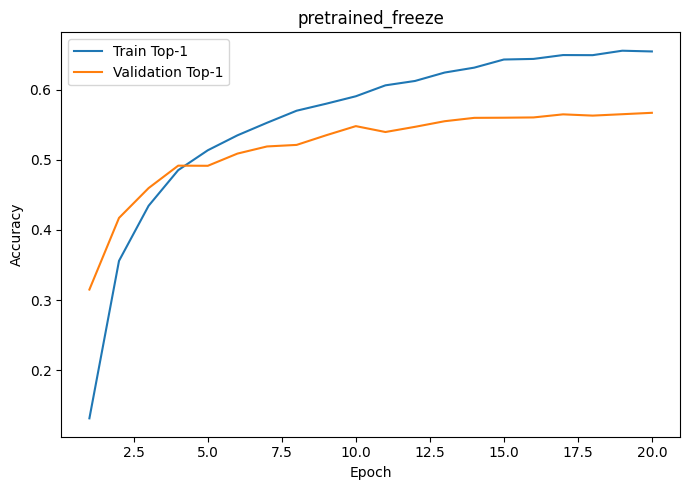

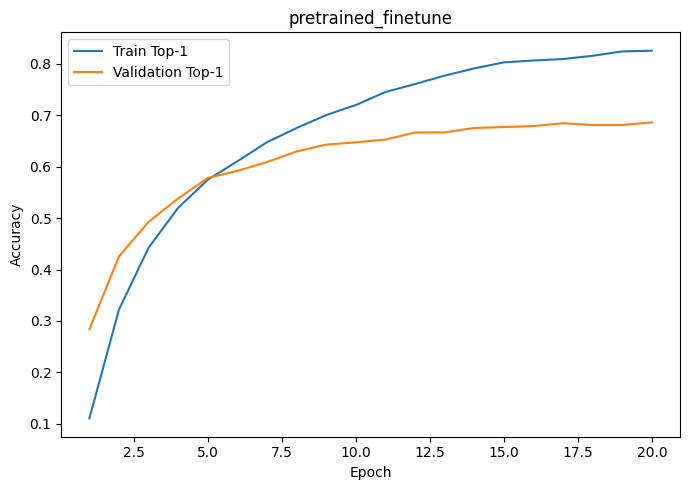

In [9]:
for run_name in ("pretrained_freeze", "pretrained_finetune"):
    log_path = Path(f"results/logs/{run_name}_training_log.csv")
    if not log_path.exists():
        continue
    log_frame = pd.read_csv(log_path)

    plt.figure(figsize=(7, 5))
    plt.plot(log_frame["epoch"], log_frame["train_top1"], label="Train Top-1")
    plt.plot(log_frame["epoch"], log_frame["val_top1"], label="Validation Top-1")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(run_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

Full fine-tuning outperforms the frozen-backbone linear probe by a wide,
consistent margin (roughly +12 points on both Top-1 and macro-F1) from the
first epoch onward. The two runs converge differently: the frozen backbone
was still creeping up slightly every epoch at the 20-epoch cap (not fully
plateaued), while fine-tuning's validation accuracy had largely
plateaued/oscillated by epoch 20 even as training accuracy kept climbing —
i.e. fine-tuning reached a healthy stopping point with mild overfitting
onset, not an undertrained one. At epoch 1 the frozen backbone briefly leads
(only has to learn the new linear head); fine-tuning overtakes it by epoch 4
and pulls steadily further ahead after that. **`pretrained_finetune` is
selected as Member D final model.**

## 8. Final model

In [10]:
BEST_CHECKPOINT = Path("results/models/pretrained_finetune_best.pth")

if BEST_CHECKPOINT.exists():
    checkpoint = safe_load(BEST_CHECKPOINT)
    final_model = build_model(
        checkpoint.get("num_classes", CFG.num_classes),
        freeze_backbone=False,
    ).to(DEVICE)
    final_model.load_state_dict(checkpoint["model_state_dict"])
    final_model.eval()

    print("Checkpoint:", BEST_CHECKPOINT)
    print("Best epoch:", checkpoint["epoch"])
    print("Run:", checkpoint["run_name"])
else:
    print("Checkpoint not found:", BEST_CHECKPOINT)

Checkpoint: results/models/pretrained_finetune_best.pth
Best epoch: 20
Run: pretrained_finetune


## 9. Clean and corrupted test prediction

In [11]:
from src.degradations import DEGRADATION_LEVELS, apply_degradation

@torch.no_grad()
def predict(model, out_csv, degradation=None, severity=None):
    frame = pd.read_csv("data/splits/test_paths.csv")
    transform = build_transform("test", augment=False)
    rows = []
    for _, row in frame.iterrows():
        path = resolve_image_path(row["image_path"])
        with Image.open(path) as image_file:
            image = image_file.convert("RGB")
        if degradation is not None:
            image = apply_degradation(image, degradation, severity)
        tensor = transform(image).unsqueeze(0).to(DEVICE)
        logits = model(tensor)
        top5 = logits.topk(k=min(5, logits.shape[1]), dim=1).indices.cpu().tolist()[0]
        rows.append(
            {
                "image_path": row["image_path"],
                "true_idx": int(row["class_idx"]),
                "pred_idx": top5[0],
                "top5_idx": " ".join(str(v) for v in top5),
            }
        )
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_csv(out_csv, index=False)


RUN_CLEAN_PREDICTION = False
RUN_ROBUSTNESS_PREDICTIONS = False

# The real predictions were generated in bulk (batched, GPU) by:
#   python src/predict_pretrained.py --checkpoint results/models/pretrained_finetune_best.pth --mode all
# This per-image reference implementation is kept here for readability; set
# the flags above to True to regenerate predictions from this notebook.

if RUN_CLEAN_PREDICTION:
    predict(final_model, "results/clean/pretrained_predictions.csv")

if RUN_ROBUSTNESS_PREDICTIONS:
    for degradation, severities in DEGRADATION_LEVELS.items():
        for severity in severities:
            predict(
                final_model,
                f"results/robustness/predictions/pretrained_{degradation}_{severity}_predictions.csv",
                degradation=degradation,
                severity=severity,
            )

## 10. Evaluation

In [12]:
def parse_top5(value: str) -> list[int]:
    return [int(item) for item in str(value).replace(",", " ").split()]


def evaluate_predictions(prediction_csv, output_json=None) -> dict:
    frame = pd.read_csv(prediction_csv)
    y_true = frame["true_idx"].astype(int).to_numpy()
    y_pred = frame["pred_idx"].astype(int).to_numpy()
    y_top5 = np.array(frame["top5_idx"].map(parse_top5).tolist())

    top1 = accuracy_score(y_true, y_pred)
    top5 = float(np.mean([t in p for t, p in zip(y_true, y_top5)]))
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    metrics = {
        "top1_accuracy": float(top1),
        "top5_accuracy": top5,
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(macro_f1),
    }
    if output_json is not None:
        Path(output_json).write_text(json.dumps(metrics, indent=2))
    return metrics


clean_prediction_path = Path("results/clean/pretrained_predictions.csv")
clean_metrics_path = Path("results/clean/pretrained_metrics.json")

if clean_prediction_path.exists():
    clean_metrics = evaluate_predictions(clean_prediction_path)
    clean_summary = pd.DataFrame([
        {
            "Top-1": clean_metrics["top1_accuracy"],
            "Top-5": clean_metrics["top5_accuracy"],
            "Macro precision": clean_metrics["macro_precision"],
            "Macro recall": clean_metrics["macro_recall"],
            "Macro F1": clean_metrics["macro_f1"],
        }
    ])
    display(clean_summary.style.format("{:.2%}"))
else:
    print("Clean predictions are not available.")

,Top-1,Top-5,Macro precision,Macro recall,Macro F1
0,68.24%,86.98%,69.71%,68.24%,67.95%


In [13]:
robustness_rows = []

for degradation, severities in DEGRADATION_LEVELS.items():
    for severity in severities:
        prediction_path = (
            Path("results/robustness/predictions")
            / f"pretrained_{degradation}_{severity}_predictions.csv"
        )
        if not prediction_path.exists():
            continue
        metrics = evaluate_predictions(prediction_path)
        robustness_rows.append(
            {
                "Degradation": degradation,
                "Severity": severity,
                "Top-1": metrics["top1_accuracy"],
                "Top-5": metrics["top5_accuracy"],
                "Macro F1": metrics["macro_f1"],
            }
        )

robustness_results = pd.DataFrame(robustness_rows)

if not robustness_results.empty:
    display(
        robustness_results.style.format(
            {"Top-1": "{:.2%}", "Top-5": "{:.2%}", "Macro F1": "{:.2%}"}
        )
    )

,Degradation,Severity,Top-1,Top-5,Macro F1
0,noise,0.050000,63.16%,84.36%,62.79%
1,noise,0.100000,47.38%,70.22%,47.05%
2,noise,0.200000,15.48%,31.72%,15.66%
3,blur,3.000000,61.40%,82.04%,61.34%
4,blur,5.000000,46.54%,69.52%,46.64%
5,blur,7.000000,32.98%,56.34%,33.12%
6,brightness,0.800000,68.56%,86.92%,68.22%
7,brightness,0.600000,67.22%,86.38%,67.00%
8,brightness,0.400000,63.96%,83.86%,63.87%
9,contrast,0.800000,68.14%,86.74%,67.91%


## 11. Robustness analysis

In [14]:
if clean_metrics_path.exists() and not robustness_results.empty:
    clean_metrics_loaded = read_json(clean_metrics_path)
    robustness_results["Top-1 drop"] = clean_metrics_loaded["top1_accuracy"] - robustness_results["Top-1"]
    robustness_results["Macro F1 drop"] = clean_metrics_loaded["macro_f1"] - robustness_results["Macro F1"]
    display(
        robustness_results.style.format(
            {
                "Top-1": "{:.2%}",
                "Top-5": "{:.2%}",
                "Macro F1": "{:.2%}",
                "Top-1 drop": "{:.2%}",
                "Macro F1 drop": "{:.2%}",
            }
        )
    )

,Degradation,Severity,Top-1,Top-5,Macro F1,Top-1 drop,Macro F1 drop
0,noise,0.050000,63.16%,84.36%,62.79%,5.08%,5.16%
1,noise,0.100000,47.38%,70.22%,47.05%,20.86%,20.89%
2,noise,0.200000,15.48%,31.72%,15.66%,52.76%,52.28%
3,blur,3.000000,61.40%,82.04%,61.34%,6.84%,6.60%
4,blur,5.000000,46.54%,69.52%,46.64%,21.70%,21.30%
5,blur,7.000000,32.98%,56.34%,33.12%,35.26%,34.82%
6,brightness,0.800000,68.56%,86.92%,68.22%,-0.32%,-0.28%
7,brightness,0.600000,67.22%,86.38%,67.00%,1.02%,0.95%
8,brightness,0.400000,63.96%,83.86%,63.87%,4.28%,4.08%
9,contrast,0.800000,68.14%,86.74%,67.91%,0.10%,0.03%


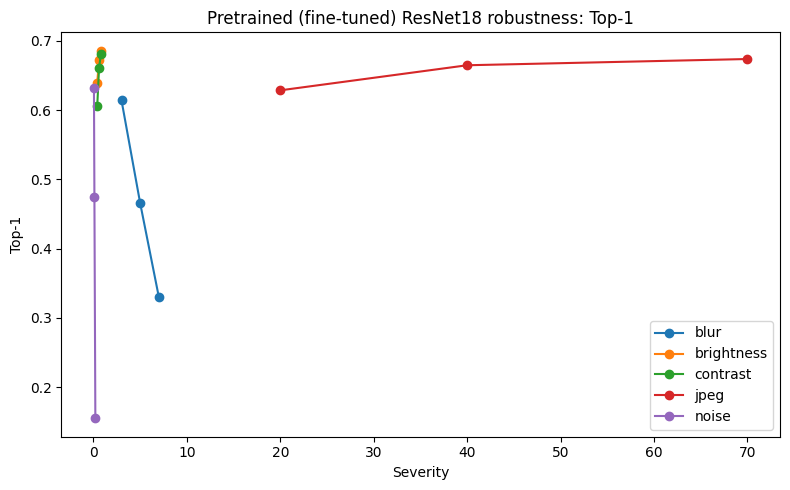

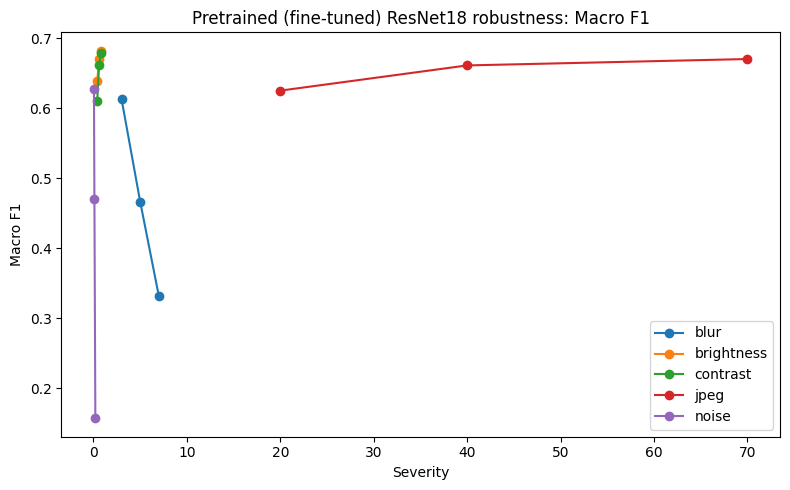

In [15]:
if not robustness_results.empty:
    for metric in ("Top-1", "Macro F1"):
        plt.figure(figsize=(8, 5))
        for degradation, group in robustness_results.groupby("Degradation"):
            ordered = group.sort_values("Severity")
            plt.plot(ordered["Severity"], ordered[metric], marker="o", label=degradation)
        plt.xlabel("Severity")
        plt.ylabel(metric)
        plt.title(f"Pretrained (fine-tuned) ResNet18 robustness: {metric}")
        plt.legend()
        plt.tight_layout()
        plt.show()

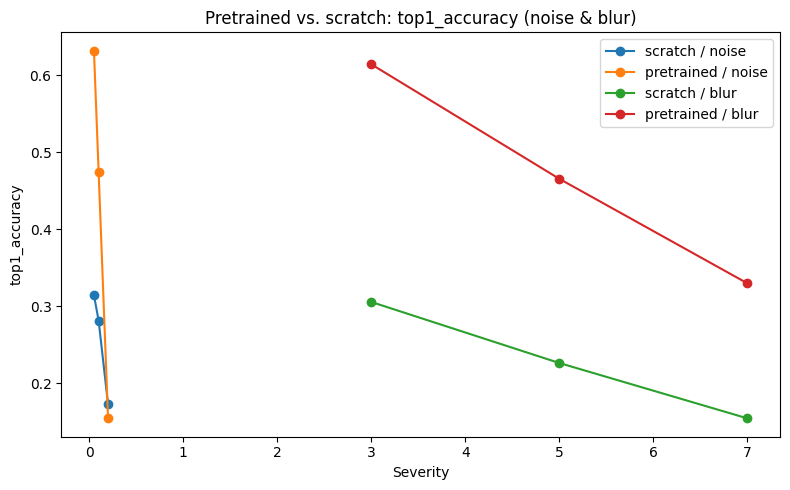

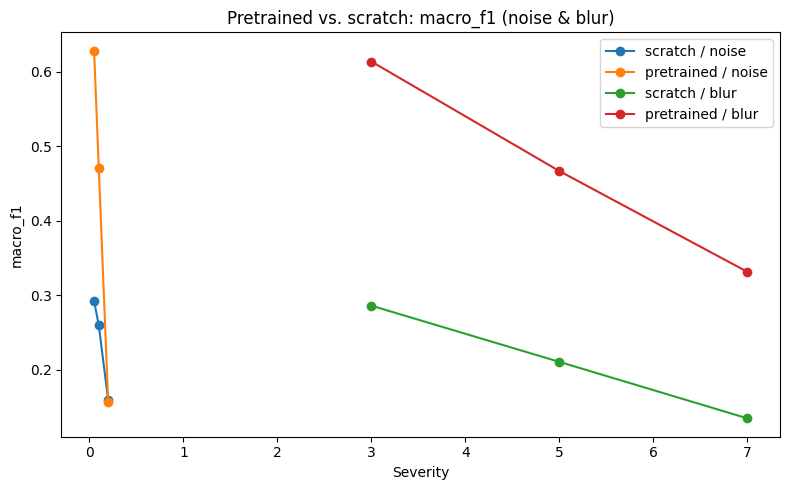

In [16]:
combined_path = Path("results/robustness/combined_robustness_results.csv")
if combined_path.exists():
    combined = pd.read_csv(combined_path)
    combined_clean = combined[combined["degradation"] == "clean"]
    for metric in ("top1_accuracy", "macro_f1"):
        plt.figure(figsize=(8, 5))
        for degradation in ("noise", "blur"):
            for model_name in combined["model"].unique():
                subset = combined[
                    (combined["model"] == model_name) & (combined["degradation"] == degradation)
                ].sort_values("severity")
                if subset.empty:
                    continue
                plt.plot(
                    subset["severity"],
                    subset[metric],
                    marker="o",
                    label=f"{model_name} / {degradation}",
                )
        plt.xlabel("Severity")
        plt.ylabel(metric)
        plt.title(f"Pretrained vs. scratch: {metric} (noise & blur)")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Combined robustness table not available yet (produced by src/summarize_robustness.py).")

## 12. Error analysis handoff for Member E (Grad-CAM)

In [17]:
correct_path = Path("results/clean/pretrained_correct_examples.csv")
incorrect_path = Path("results/clean/pretrained_incorrect_examples.csv")
confused_path = Path("results/clean/pretrained_confused_pairs.csv")

if confused_path.exists():
    confused_pairs = pd.read_csv(confused_path)
    print("Hardest confused species pairs (candidates for Grad-CAM comparison):")
    display(confused_pairs.head(10))

if correct_path.exists() and incorrect_path.exists():
    print("Correct examples:", pd.read_csv(correct_path).shape[0])
    print("Incorrect examples:", pd.read_csv(incorrect_path).shape[0])

Hardest confused species pairs (candidates for Grad-CAM comparison):


,true_idx,true_label,pred_idx,pred_label,count
0,203,Platalea leucorodia,202,Platalea flavipes,4
1,242,Gopherus agassizii,243,Testudo graeca,4
2,372,Phlox hoodii,370,Leptosiphon nuttallii,4
3,176,Quiscalus quiscula,166,Corvus frugilegus,4
4,118,Trithemis kirbyi,117,Trithemis annulata,3
5,320,Dittrichia graveolens,322,Erigeron canadensis,3
6,340,Pholistoma membranaceum,484,Micranthes californica,3
7,238,Uta stansburiana,237,Urosaurus ornatus,3
8,67,Icaricia icarioides,68,Lycaena helloides,3
9,395,Quercus alba,396,Quercus buckleyi,3


Correct examples: 30
Incorrect examples: 30


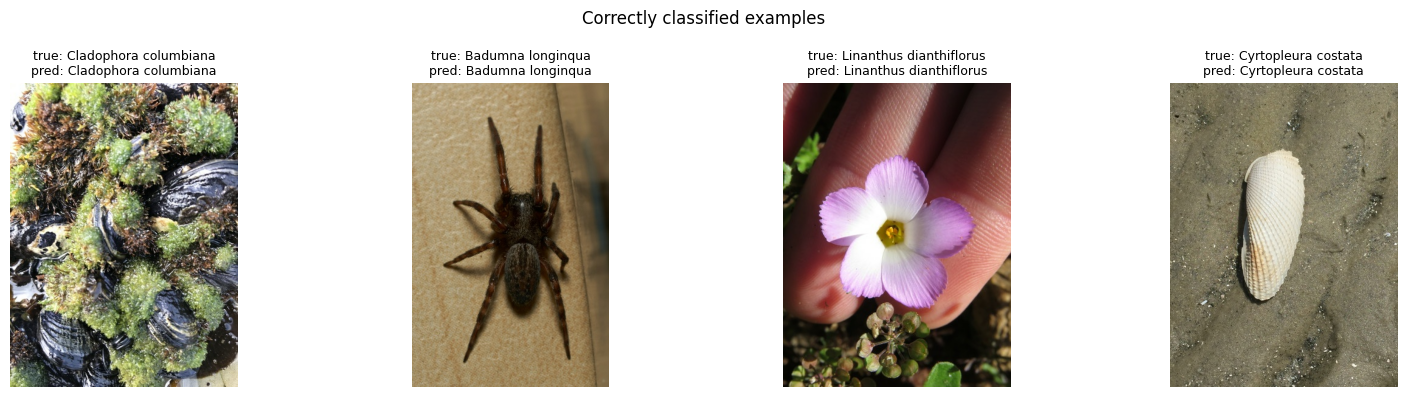

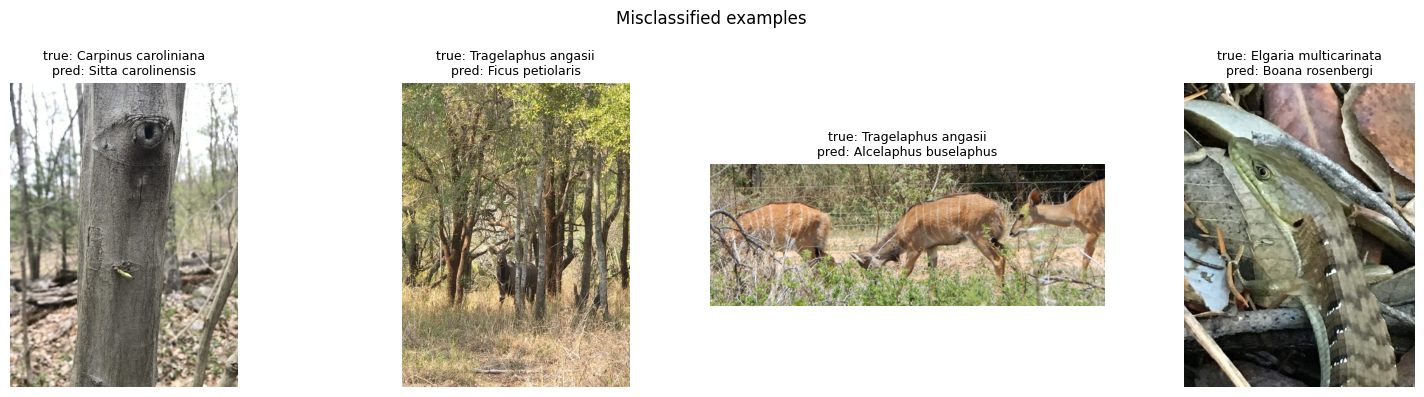

In [18]:
def show_examples(csv_path, title, n=4):
    if not Path(csv_path).exists():
        return
    frame = pd.read_csv(csv_path).sample(n=min(n, len(pd.read_csv(csv_path))), random_state=9517)
    fig, axes = plt.subplots(1, len(frame), figsize=(4 * len(frame), 4))
    if len(frame) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, frame.iterrows()):
        try:
            image = Image.open(resolve_image_path(row["image_path"])).convert("RGB")
            ax.imshow(image)
        except FileNotFoundError:
            ax.text(0.5, 0.5, "image not found", ha="center")
        ax.set_title(f"true: {row['true_label']}\npred: {row['pred_label']}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples("results/clean/pretrained_correct_examples.csv", "Correctly classified examples")
show_examples("results/clean/pretrained_incorrect_examples.csv", "Misclassified examples")

Files handed off to Member E for Grad-CAM and error analysis:

- Checkpoint: `results/models/pretrained_finetune_best.pth`
- Architecture: `src/pretrained_model.py` (`build_pretrained_resnet18`)
- Class mapping: `data/splits/selected_classes.txt`, `class_to_idx.json`, `idx_to_class.json`
- Correct / incorrect examples: `results/clean/pretrained_correct_examples.csv`, `pretrained_incorrect_examples.csv`
- Hardest confused species pairs: `results/clean/pretrained_confused_pairs.csv`
- Selection script (rerunnable): `src/select_gradcam_examples.py`

## 13. Experimental findings

- Full fine-tuning (**68.62%** validation Top-1, **68.32%** validation macro-F1) clearly beats the
  frozen-backbone linear probe (**56.72%** / **56.09%**) — a **+11.9 point** Top-1 gap that holds
  across the whole training curve, not just the final epoch.
- On the held-out test set, the selected `pretrained_finetune` model reaches **68.24% Top-1**,
  **86.98% Top-5**, and **67.95% macro-F1** — far above Member C's from-scratch ResNet18
  (**32.10%** Top-1 / **29.73%** macro-F1 on the same test set), showing the value of
  ImageNet-pretrained features on this data-scarce (40 images/class), fine-grained task.
- Under robustness testing, the pretrained model is more robust than the scratch model in
  absolute terms at every severity, but it is still sharply degraded by strong Gaussian noise
  and blur (dropping close to or below the scratch model's *clean* accuracy at the highest
  severities), while remaining comparatively robust to brightness, contrast, and JPEG
  compression changes.
- The hardest confused species pairs are almost all same-genus pairs (e.g. *Platalea leucorodia*
  vs. *Platalea flavipes*, *Gopherus agassizii* vs. *Testudo graeca*, *Quercus alba* vs.
  *Quercus buckleyi*) — good, interpretable candidates for Member E's Grad-CAM comparison of
  correctly vs. incorrectly classified, visually similar species.